In [1]:
import time
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
from torchvision import datasets, transforms, utils
from torch.utils.data import DataLoader
%cd "C:/Users/mateo/Desktop/polymath"
from src.driftXpress import *
from src.eval import *
torch.manual_seed(7)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using:", device)


C:\Users\mateo\Desktop\polymath
Using: cuda


In [2]:
transform = transforms.ToTensor()

SELECTED_DIGITS = (0, 8, 2, 4, 7, 9)
DIGIT_TO_CLASS = {digit: index for index, digit in enumerate(SELECTED_DIGITS)}
CLASS_TO_DIGIT = np.asarray(SELECTED_DIGITS)

train_data = datasets.MNIST("data", train=True, download=True, transform=transform)
test_data = datasets.MNIST("data", train=False, download=True, transform=transform)

def keep_selected_digits(dataset):
    selected = torch.tensor(SELECTED_DIGITS, dtype=dataset.targets.dtype)
    mask = torch.isin(dataset.targets, selected)
    dataset.data = dataset.data[mask]
    raw_targets = dataset.targets[mask]
    dataset.targets = torch.tensor(
        [DIGIT_TO_CLASS[int(digit)] for digit in raw_targets],
        dtype=torch.long,
    )
    return dataset

train_data = keep_selected_digits(train_data)
test_data = keep_selected_digits(test_data)

BATCH_SIZE = 500

train_loader = DataLoader(
    train_data,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)
test_loader = DataLoader(
    test_data,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)

print("Selected digits:", SELECTED_DIGITS)
print("Train samples:", len(train_data))
print("Test samples:", len(test_data))


Selected digits: (0, 8, 2, 4, 7, 9)
Train samples: 35788
Test samples: 6005


In [3]:
class f(nn.Module):
    def __init__(self, input_dim=784, latent_dim=16, num_classes=6, label_dim=16):
        super().__init__()
        self.latent_dim = latent_dim
        self.num_classes = num_classes
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 192), nn.LeakyReLU(0.2),
            nn.Linear(192, 96), nn.LeakyReLU(0.2),
        )
        self.fc_mu = nn.Linear(96, latent_dim)
        self.fc_var = nn.Linear(96, latent_dim)
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 96), nn.LeakyReLU(0.2),
            nn.Linear(96, 192), nn.LeakyReLU(0.2),
            nn.Linear(192, input_dim), nn.Sigmoid(),
        )
        self.embedding = nn.Embedding(num_classes, label_dim)
        self.generator = nn.Sequential(
            nn.Linear(latent_dim + label_dim, 48), nn.SiLU(),
            nn.Linear(48, 48), nn.SiLU(),
            nn.Linear(48, 48), nn.SiLU(),
            nn.Linear(48, latent_dim),
        )

    def reparameterize(self, mu, logvar):
        return mu + torch.randn_like(logvar) * torch.exp(0.5 * logvar)

    def get_latent(self, x):
        h = self.encoder(x)
        mu, logvar = self.fc_mu(h), self.fc_var(h)
        return mu, logvar, self.reparameterize(mu, logvar)

    def encode_mu(self, x):
        return self.fc_mu(self.encoder(x))

    def decode(self, z):
        return self.decoder(z)

    def generate(self, noise, labels):
        h = torch.cat([noise, self.embedding(labels.long())], dim=1)
        z = self.generator(h)
        return z, self.decode(z)


In [35]:
model = f()
total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params}")
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {trainable_params}")

Total parameters: 351088
Trainable parameters: 351088


In [4]:
# Keep the drift field fixed while allowing gradients through the re-encoded latent.
def drift_loss(generated, landmarks, K_uu_inv_sqrt, Ap, bp, T):
    with torch.no_grad():
        V = compute_V(generated.detach(), landmarks, K_uu_inv_sqrt, Ap, bp, T)
        frozen_targets = (generated.detach() + V).detach()
    return F.mse_loss(generated, frozen_targets), V


In [5]:
def build_conditional_drift_cache(model, data_loader, num_classes, num_landmarks, T):
    # Build fixed class-conditional attraction summaries once.
    model.eval()
    references = {digit: [] for digit in range(num_classes)}
    with torch.no_grad():
        for images, labels in data_loader:
            x = images.to(device, non_blocking=True).flatten(start_dim=1)
            _, _, z = model.get_latent(x)
            labels = labels.to(device, non_blocking=True)
            for digit in range(num_classes):
                mask = labels == digit
                if mask.any():
                    references[digit].append(z[mask].detach())

    cache = {}
    bank = []
    for digit in range(num_classes):
        if not references[digit]:
            raise ValueError(f"No reference samples found for digit {digit}.")
        support = torch.cat(references[digit], dim=0)
        bank.append(support)
        landmarks = select_landmarks(support, num_landmarks)
        W = build_nystrom_cache(landmarks, T)
        A, b = pre_compute_summaries(support, landmarks, W, T)
        cache[digit] = (landmarks, W, A, b)
    return cache, torch.cat(bank, dim=0)


def conditional_drift_loss(generated, labels, cache, T):
    total = generated.new_zeros(())
    field = torch.zeros_like(generated)
    batch_size = generated.shape[0]
    for digit_tensor in torch.unique(labels):
        digit = int(digit_tensor.item())
        mask = labels == digit
        landmarks, W, A, b = cache[digit]
        digit_loss, digit_field = drift_loss(
            generated[mask], landmarks, W, A, b, T
        )
        total = total + (mask.float().sum() / batch_size) * digit_loss
        field[mask] = digit_field
    return total, field

def training_loop(num_epochs, T, num_landmarks,
                  lambda_kl, lambda_drift, lambda_var, lambda_cov,
                  batch_size=1000, lr=1e-3):
    model = f(784, LATENT_DIM, NUM_CLASSES).to(device)
    optimizer = optim.AdamW(model.parameters(), lr=lr)
    train_losses, recon_losses, kl_losses = [], [], []
    drift_losses, var_losses, covar_losses = [], [], []
    average_V, evolution = [], []

    print("Building fixed conditional attraction caches...")
    t0 = time.perf_counter()
    cache, _ = build_conditional_drift_cache(
        model, train_loader, NUM_CLASSES, num_landmarks, T
    )
    print(f"Fixed attraction caches built in {(time.perf_counter() - t0) / 60:.2f} minutes")
    print("Fully joint conditional training started")
    snapshots = set(range(0, num_epochs + 1, max(1, num_epochs // 5)))
    snapshots.add(num_epochs)

    for epoch in range(num_epochs + 1):
        model.train()
        items = {k: 0.0 for k in
                 ("total", "recon", "kl", "drift", "var", "covar", "V")}
        last_pos, last_neg = None, None
        for images, labels in train_loader:
            x = images.to(device, non_blocking=True).flatten(start_dim=1)
            labels = labels.to(device, non_blocking=True)
            noise = torch.randn(x.shape[0], model.latent_dim, device=device)
            mu, logvar, z_pos = model.get_latent(x)
            x_recon = model.decode(z_pos)
            z_raw, x_neg = model.generate(noise, labels)
            z_neg = model.encode_mu(x_neg)

            L_drift, V = conditional_drift_loss(z_neg, labels, cache, T)
            L_var = variance_loss(mu) + variance_loss(z_neg)
            L_cov = covariance_loss(mu) + covariance_loss(z_neg)
            L_recon, L_kl = recon_loss(x_recon, x), kl_loss(mu, logvar)
            loss = (L_recon + lambda_kl * L_kl + lambda_drift * L_drift
                    + lambda_var * L_var + lambda_cov * L_cov)
            if not torch.isfinite(loss):
                raise FloatingPointError(f"Non-finite loss at epoch {epoch}: {loss.item()}")
            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            optimizer.step()

            items["total"] += loss.item()
            items["recon"] += L_recon.item()
            items["kl"] += L_kl.item()
            items["drift"] += L_drift.item()
            items["var"] += L_var.item()
            items["covar"] += L_cov.item()
            items["V"] += V.norm(dim=1).mean().item()
            last_pos, last_neg = z_pos.detach(), z_neg.detach()

        n = len(train_loader)
        for key in items:
            items[key] /= n
        train_losses.append(items["total"])
        recon_losses.append(items["recon"])
        kl_losses.append(items["kl"])
        drift_losses.append(items["drift"])
        var_losses.append(items["var"])
        covar_losses.append(items["covar"])
        average_V.append(items["V"])
        if epoch in snapshots:
            evolution.append({"epoch": epoch, "pos": last_pos.cpu().numpy(),
                               "neg": last_neg.cpu().numpy()})
        if epoch < 20 or epoch % 10 == 0 or epoch == num_epochs:
            print(f"-------- Epoch {epoch} --------")
            print(f"total={items['total']:.6f}")
            print(f"recon={items['recon']:.6f}")
            print(f"kl={items['kl']:.6f}    scaled={lambda_kl * items['kl']:.6f}")
            print(f"drift={items['drift']:.6f}    scaled={lambda_drift * items['drift']:.6f}")
            print(f"var={items['var']:.6f}    scaled={lambda_var * items['var']:.6f}")
            print("distances", torch.cdist(z_pos[:50], z_pos[:50]).mean().item())
            print(f"covar={items['covar']:.6f}    scaled={lambda_cov * items['covar']:.6f}")
            print(f"average |V|={items['V']:.6f}")
            print(f"latent std positive={last_pos.std(dim=0).mean().item():.6f}")
            print(f"latent std negative={last_neg.std(dim=0).mean().item():.6f}")

    elapsed = (time.perf_counter() - t0) / 60
    print(f"Finished. Training took {elapsed:.2f} minutes")
    return (model, train_losses, recon_losses, kl_losses,
            drift_losses, var_losses, covar_losses, average_V, evolution)


In [24]:
# Algorithm 3: fully joint conditional training with image re-encoding for drift.
NUM_CLASSES = 6
LATENT_DIM = 32
NUM_EPOCHS = 100
NUM_LANDMARKS = 200
TEMPERATURE = 2
LAMBDA_KL = 1e-5
LAMBDA_DRIFT = 30.0
LAMBDA_VAR = 0.1
LAMBDA_COV = 0.3

f_trained, losses, recon_losses, kl_losses, drift_losses, var_losses, covar_losses, average_V, evolution = training_loop(
    NUM_EPOCHS, TEMPERATURE, NUM_LANDMARKS, LAMBDA_KL, LAMBDA_DRIFT,
    LAMBDA_VAR, LAMBDA_COV,
    batch_size=BATCH_SIZE, lr=1e-3,
)


Building fixed conditional attraction caches...
Fixed attraction caches built in 0.13 minutes
Fully joint conditional training started
-------- Epoch 0 --------
total=0.421108
recon=0.104013
kl=0.180237    scaled=0.000002
drift=0.000684    scaled=0.020517
var=2.965745    scaled=0.296574
distances 8.073741912841797
covar=0.000003    scaled=0.000001
average |V|=0.114500
latent std positive=1.057622
latent std negative=0.012089
-------- Epoch 1 --------
total=0.362215
recon=0.068002
kl=2.718728    scaled=0.000027
drift=0.000182    scaled=0.005449
var=2.864925    scaled=0.286492
distances 10.371077537536621
covar=0.007482    scaled=0.002245
average |V|=0.075107
latent std positive=1.305312
latent std negative=0.038276
-------- Epoch 2 --------
total=0.356096
recon=0.066318
kl=9.979547    scaled=0.000100
drift=0.000191    scaled=0.005727
var=2.805776    scaled=0.280578
distances 11.065817832946777
covar=0.011245    scaled=0.003374
average |V|=0.076805
latent std positive=1.494140
latent std

In [25]:
f_trained.train()
images, labels = next(iter(train_loader))
x = images.to(device).flatten(start_dim=1)
labels = labels.to(device)
noise = torch.randn(x.shape[0], f_trained.latent_dim, device=device)
mu, logvar, z_pos = f_trained.get_latent(x)
z_raw, x_neg = f_trained.generate(noise, labels)
z_neg = f_trained.encode_mu(x_neg)
cache, _ = build_conditional_drift_cache(
    f_trained, train_loader, NUM_CLASSES, NUM_LANDMARKS, TEMPERATURE
)
L_drift, V = conditional_drift_loss(z_neg, labels, cache, TEMPERATURE)
print(gradient_report(L_drift, f_trained))


{'encoder': {'total_norm': 0.7401347979903221, 'nonzero_parameters': 6, 'parameter_count': 8}, 'decoder': {'total_norm': 0.17681240988895297, 'nonzero_parameters': 6, 'parameter_count': 6}, 'generator': {'total_norm': 0.2759304931387305, 'nonzero_parameters': 8, 'parameter_count': 8}, 'other': {'total_norm': 0.0037308952305465937, 'nonzero_parameters': 1, 'parameter_count': 1}}


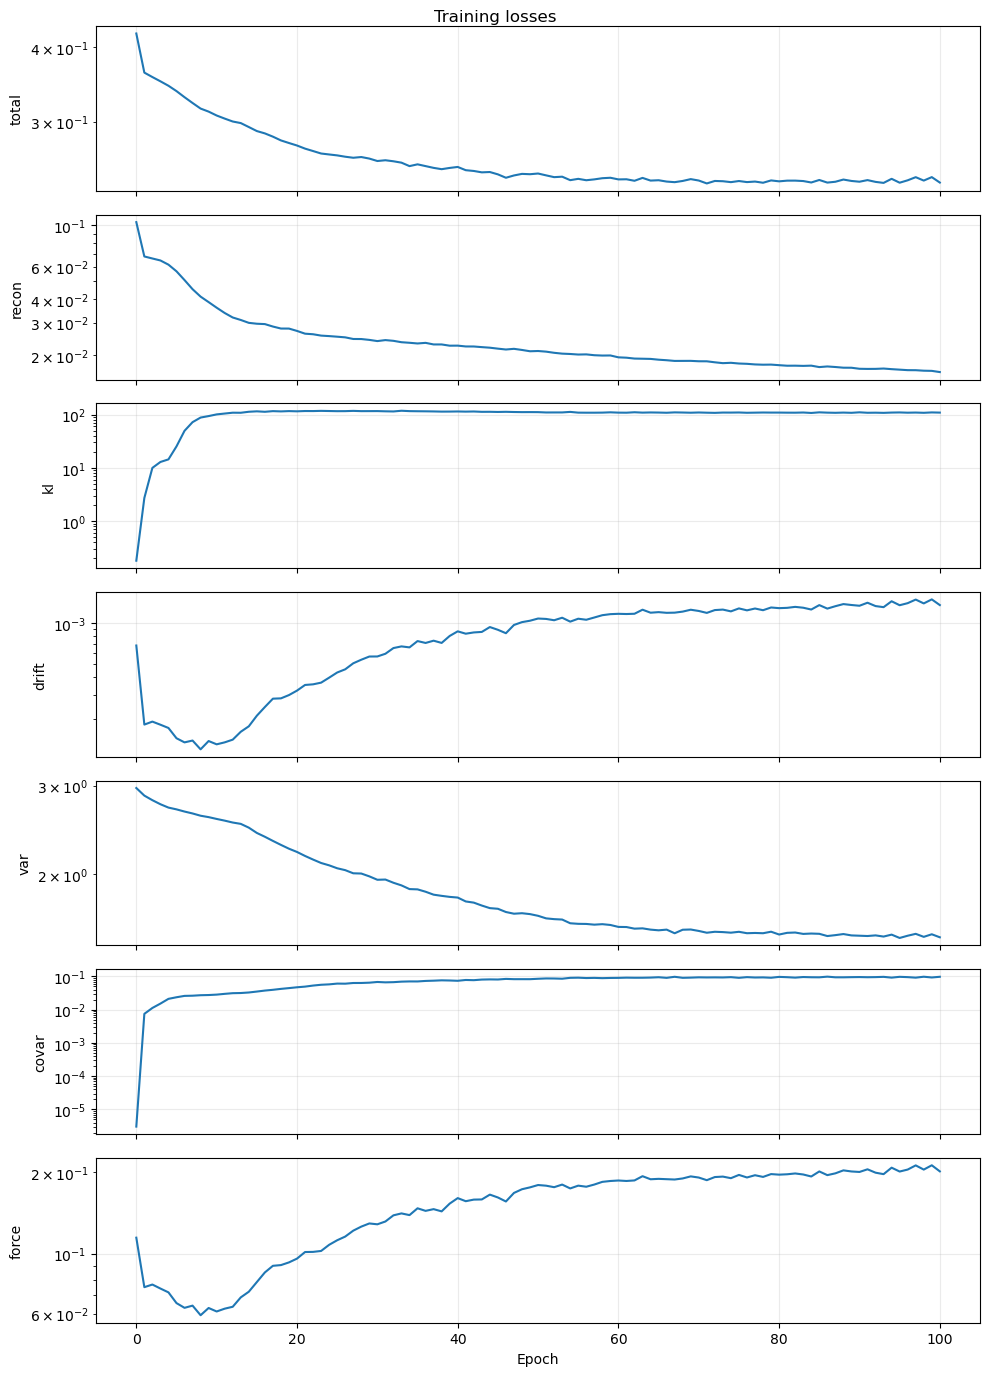

In [26]:
history = {
    "total": losses, "recon": recon_losses, "kl": kl_losses,
    "drift": drift_losses, "var": var_losses,
    "covar": covar_losses, "force": average_V,
}
fig, axes = plot_loss_history(history)
plt.show()


In [27]:
f_trained.eval()
real_latents = []
real_class_labels = []
with torch.no_grad():
    for images, labels in test_loader:
        x = images.to(device).flatten(start_dim=1)
        mu, logvar, z = f_trained.get_latent(x)
        real_latents.append(mu.cpu())
        real_class_labels.append(labels)
real_latents = torch.cat(real_latents).numpy()
real_class_labels = torch.cat(real_class_labels).numpy()
real_labels = CLASS_TO_DIGIT[real_class_labels]

n_samples = real_latents.shape[0]
with torch.no_grad():
    noise = torch.randn(n_samples, f_trained.latent_dim, device=device)
    generated_labels_tensor = torch.randint(
        0, f_trained.num_classes, (n_samples,), device=device
    )
    generated_latents, generated_images = f_trained.generate(
        noise, generated_labels_tensor
    )
generated_latents = generated_latents.cpu().numpy()
generated_images = generated_images.cpu().numpy()
generated_class_labels = generated_labels_tensor.cpu().numpy()
generated_labels = CLASS_TO_DIGIT[generated_class_labels]


In [28]:
real_pixels = (
    test_data.data.float()
    .reshape(len(test_data), -1)
    .numpy() / 255.0
)

generated_pixels = (
    generated_images.detach().cpu().numpy()
    if hasattr(generated_images, "detach")
    else np.asarray(generated_images)
)
generated_pixels = generated_pixels.reshape(len(generated_pixels), -1)

metrics = evaluate_generation(
    real_features=real_pixels,
    generated_features=generated_pixels,
    generated_labels=generated_class_labels,
    n_classes=NUM_CLASSES,
    mmd_max_samples=128,
)

for name, value in metrics.items():
    print(f"{name}: {value:.6f}")

print("\nPer-digit pixel metrics:")
for class_id, digit in enumerate(SELECTED_DIGITS):
    real_mask = real_class_labels == class_id
    generated_mask = generated_class_labels == class_id

    if generated_mask.any():
        digit_metrics = evaluate_generation(
            real_features=real_pixels[real_mask],
            generated_features=generated_pixels[generated_mask],
            mmd_max_samples=128,
        )
        print(f"digit {digit}: {digit_metrics}")


sliced_wasserstein: 0.145378
mmd_rbf: 0.150643
fid: 60.209453
class_coverage: 1.000000
class_entropy: 0.999966

Per-digit pixel metrics:
digit 0: {'sliced_wasserstein': 0.19980668356330444, 'mmd_rbf': 0.2776078848754091, 'fid': 86.51641311877741}
digit 8: {'sliced_wasserstein': 0.17732782008315615, 'mmd_rbf': 0.27082251541581126, 'fid': 80.43971367510898}
digit 2: {'sliced_wasserstein': 0.17174215510123558, 'mmd_rbf': 0.20660922266052206, 'fid': 74.44712362943484}
digit 4: {'sliced_wasserstein': 0.14669024576668535, 'mmd_rbf': 0.21051284046967433, 'fid': 66.08349432131594}
digit 7: {'sliced_wasserstein': 0.15428814892512444, 'mmd_rbf': 0.2439776181030835, 'fid': 68.3462056138944}
digit 9: {'sliced_wasserstein': 0.16125012316152537, 'mmd_rbf': 0.2611251028093424, 'fid': 69.64368034973907}


In [29]:
print("Real latent mean:", real_latents.mean(axis=0).mean())
print("Generated latent mean:", generated_latents.mean(axis=0).mean())
print("Real latent std:", real_latents.std(axis=0).mean())
print("Generated latent std:", generated_latents.std(axis=0).mean())


Real latent mean: -0.16259888
Generated latent mean: -0.059301373
Real latent std: 1.0613971
Generated latent std: 1.8875786


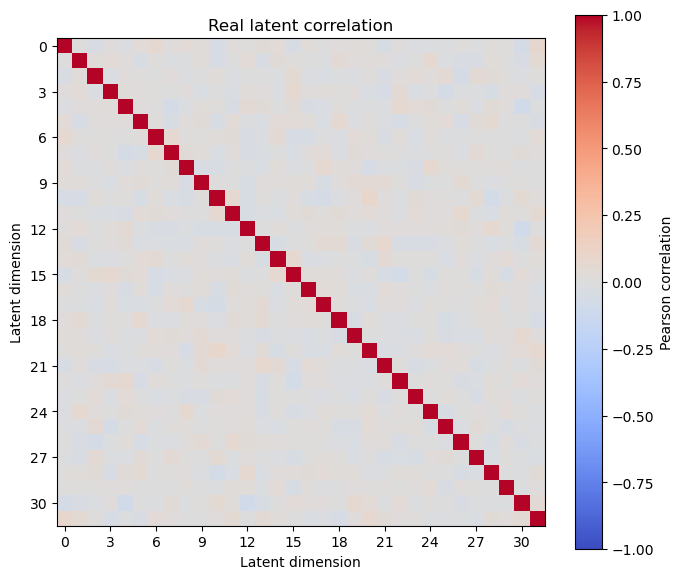

In [30]:
fig, ax, real_correlation = plot_latent_correlation(
    latents=real_latents,
    annotate=False,
)
ax.set_title("Real latent correlation")
plt.show()


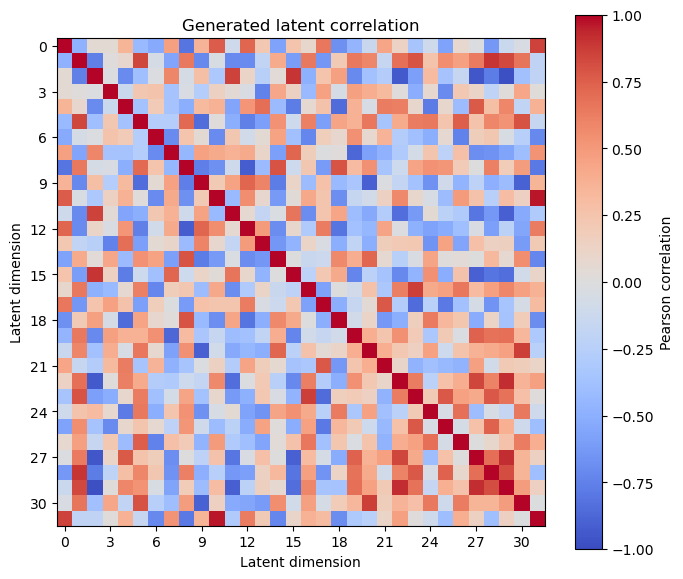

In [31]:
fig, ax, generated_correlation = plot_latent_correlation(
    latents=generated_latents,
    annotate=False,
)
ax.set_title("Generated latent correlation")
plt.show()


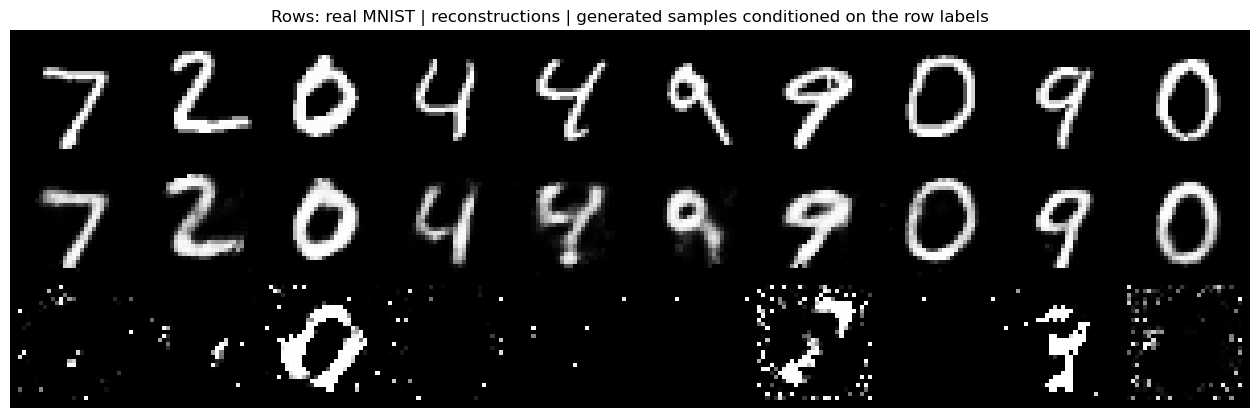

In [32]:
@torch.no_grad()
def show_mnist_results(model, samples=10):
    model.eval()
    images, labels = next(iter(test_loader))
    images = images[:samples].to(device).flatten(start_dim=1)
    labels = labels[:samples].to(device)

    _, _, z_pos = model.get_latent(images)
    reconstructions = model.decode(z_pos).view(-1, 1, 28, 28).cpu()

    noise = torch.randn(samples, model.latent_dim, device=device)
    _, generated = model.generate(noise, labels)
    generated = generated.view(-1, 1, 28, 28).cpu()

    comparison = torch.cat([
        images.view(-1, 1, 28, 28).cpu(),
        reconstructions,
        generated,
    ])
    grid = utils.make_grid(comparison, nrow=samples, padding=2)
    plt.figure(figsize=(16, 5))
    plt.imshow(grid.permute(1, 2, 0))
    plt.axis("off")
    plt.title(
        "Rows: real MNIST | reconstructions | generated samples "
        "conditioned on the row labels"
    )
    plt.show()


show_mnist_results(f_trained)


C:\Users\mateo\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


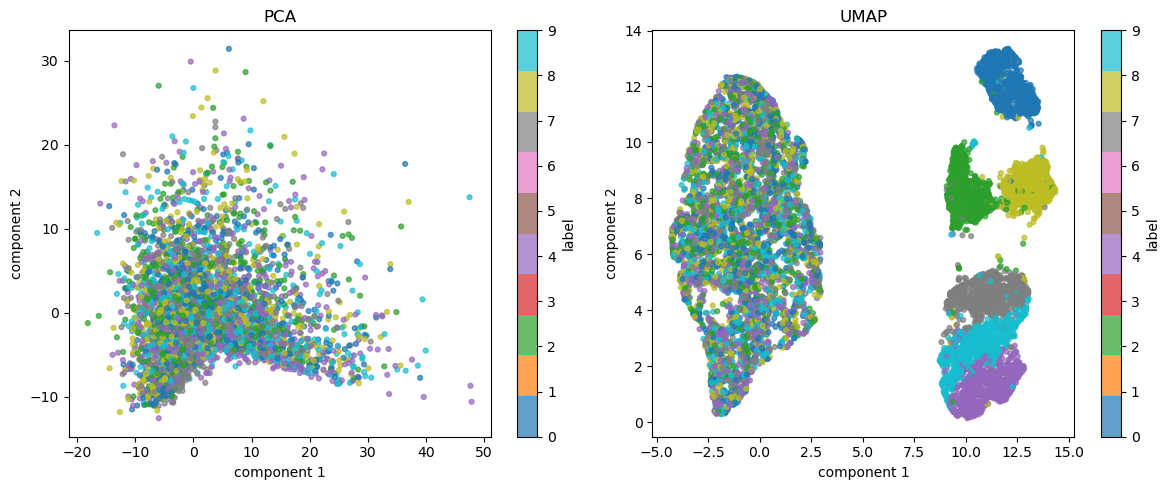

In [33]:
fig, axes = plot_latent_projections(
    latents=np.concatenate([real_latents, generated_latents]),
    labels=np.concatenate([real_labels, generated_labels]),
    methods=("pca", "umap"),
)
plt.show()


C:\Users\mateo\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


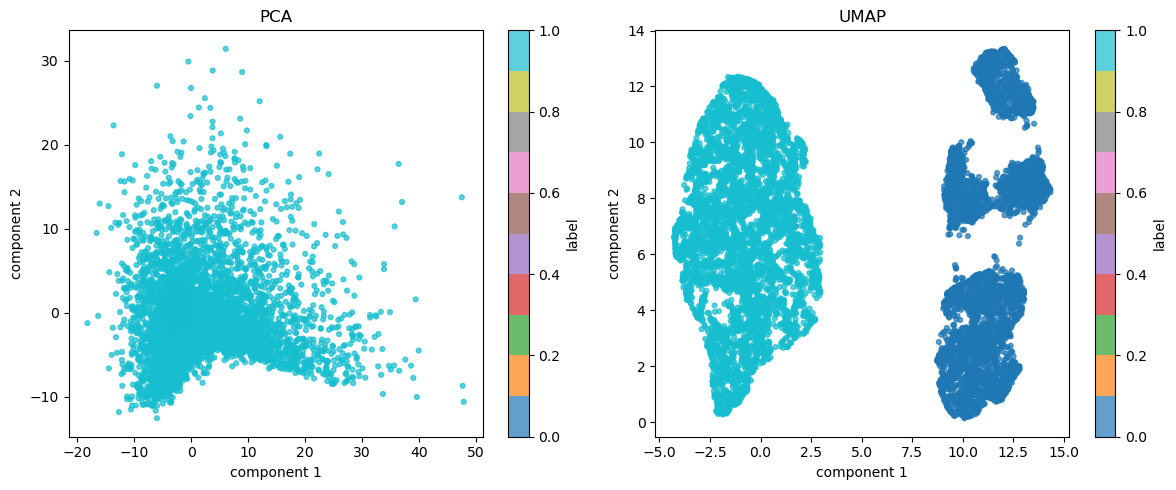

In [34]:
fig, axes = plot_latent_projections(
    latents=np.concatenate([real_latents, generated_latents]),
    labels=np.concatenate([
        np.zeros(len(real_latents)),
        np.ones(len(generated_latents)),
    ]),
    methods=("pca", "umap"),
)

plt.show()
